# Predicting toxicity from molecular structure

We train one classifier per assay and ask three questions:
1. **How should we evaluate?** Random split vs scaffold split
2. **Which features and models work best?**
3. **When can we trust a prediction?** Similarity to the training data
4. **What did the model learn?** Toxic fragments
5. **How useful is it in practice?** Screening enrichment

Metrics, since classes are imbalanced:
- **ROC-AUC:** the probability that a random active molecule is ranked above a random inactive one. 0.5 is chance, 1.0 is perfect.
- **Average precision (AP):** the area under the precision–recall curve. It must be compared with the assay's **base rate** (the share of actives), which is what a random model would score.

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rdkit import Chem, DataStructs
from rdkit.Chem import Draw, rdFingerprintGenerator
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT / "src"))
import style
from featurize import ASSAYS, FP_BITS, FP_RADIUS
style.apply()

FIG = ROOT / "figures"
def save_fig(name):
    plt.tight_layout()
    plt.savefig(FIG / f"{name}.png", dpi=120)

PROC = ROOT / "data" / "processed"
mols = pd.read_parquet(PROC / "molecules.parquet")
desc = pd.read_parquet(PROC / "descriptors.parquet")
fps = np.load(PROC / "fingerprints.npy")

FEATURES = {
    "Fingerprint": fps.astype(np.float32),
    "Descriptors": desc.to_numpy(dtype=np.float32),
    "Fingerprint + descriptors": np.hstack([fps, desc.to_numpy()]).astype(np.float32),
}
SEED = 0

In [2]:
def random_forest():
    return make_pipeline(SimpleImputer(strategy="median"),
                         RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample",
                                                n_jobs=-1, random_state=SEED))

def logistic():
    return make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                         LogisticRegression(C=0.05, class_weight="balanced", max_iter=3000))

def boosting():
    return HistGradientBoostingClassifier(max_iter=150, learning_rate=0.1, class_weight="balanced", random_state=SEED)

def evaluate(X, make_model, split, keep_predictions=False):
    """Train one model per assay on the 'train' molecules of `split`, score on 'test'.
    Molecules not tested in an assay are left out of that assay's training and test data."""
    train = (mols[split] == "train").to_numpy()
    test = (mols[split] == "test").to_numpy()
    rows, preds = [], {}
    for assay in ASSAYS:
        y = mols[assay].to_numpy()
        tr, te = train & ~np.isnan(y), test & ~np.isnan(y)
        model = make_model().fit(X[tr], y[tr])
        p = model.predict_proba(X[te])[:, 1]
        rows.append({"assay": assay, "ROC-AUC": roc_auc_score(y[te], p),
                     "AP": average_precision_score(y[te], p), "base rate": y[te].mean(), "test molecules": te.sum()})
        if keep_predictions:
            preds[assay] = pd.Series(p, index=np.where(te)[0])
    out = pd.DataFrame(rows).set_index("assay")
    return (out, preds) if keep_predictions else out

## 1. Random split vs scaffold split

- **Random split:** 80% of molecules for training, 10% for testing, chosen at random.
- **Scaffold split:** molecules are grouped by scaffold (see notebook 01), and whole groups go to train or test. Every test molecule has a scaffold the model **has never seen**.

The scaffold split mimics the real question a chemist asks: *"I've designed a new compound. Is it toxic?"*

In [3]:
t = time.time()
X = FEATURES["Fingerprint + descriptors"]
res_random = evaluate(X, random_forest, "split_random")
res_scaffold, preds_scaffold = evaluate(X, random_forest, "split_scaffold", keep_predictions=True)
print(f"({time.time() - t:.0f}s)")
pd.DataFrame({"Random split": res_random[["ROC-AUC", "AP"]].mean(),
              "Scaffold split": res_scaffold[["ROC-AUC", "AP"]].mean()}).round(3)

(58s)


,Random split,Scaffold split
ROC-AUC,0.830,0.785
AP,0.482,0.409


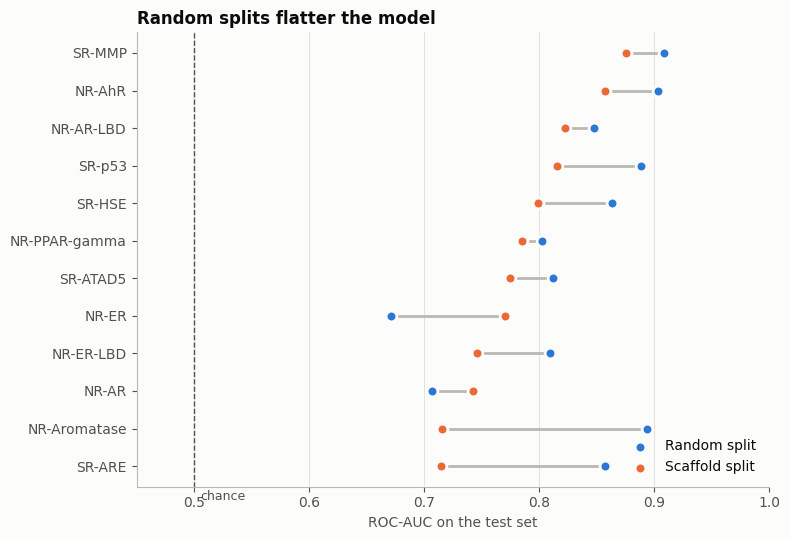

In [4]:
order = res_scaffold["ROC-AUC"].sort_values().index
fig, ax = plt.subplots(figsize=(8, 5.5))
y = np.arange(len(order))
ax.hlines(y, res_scaffold.loc[order, "ROC-AUC"], res_random.loc[order, "ROC-AUC"], color=style.NEUTRAL, lw=2)
ax.scatter(res_random.loc[order, "ROC-AUC"], y, color=style.BLUE, s=60, zorder=3, label="Random split",
           edgecolor=style.SURFACE, lw=2)
ax.scatter(res_scaffold.loc[order, "ROC-AUC"], y, color=style.ORANGE, s=60, zorder=3, label="Scaffold split",
           edgecolor=style.SURFACE, lw=2)
ax.set_yticks(y, order)
ax.axvline(0.5, color=style.TEXT_2, lw=1, ls="--")
ax.text(0.505, -0.9, "chance", fontsize=9, color=style.TEXT_2)
ax.set(xlim=(0.45, 1), xlabel="ROC-AUC on the test set", title="Random splits flatter the model")
ax.legend(loc="lower right")
ax.grid(axis="y", visible=False)
save_fig("08_random_vs_scaffold")
plt.show()

The same model looks better under a random split (mean ROC-AUC 0.83, average precision 0.48) than under a scaffold split (0.79 and 0.41), and the gap appears in most assays.
**Why?** Under a random split, most test molecules have a close relative in the training data. We can measure this with the **Tanimoto similarity** between fingerprints (0 = nothing in common, 1 = identical) to each test molecule's nearest training neighbour:

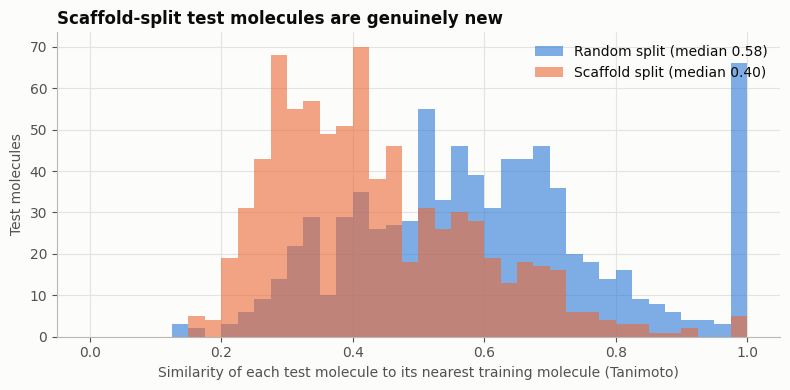

In [5]:
bitvectors = [DataStructs.CreateFromBitString("".join(map(str, row))) for row in fps]

def nearest_train_similarity(split):
    train_fps = [bitvectors[i] for i in np.where(mols[split] == "train")[0]]
    test_idx = np.where(mols[split] == "test")[0]
    return pd.Series([max(DataStructs.BulkTanimotoSimilarity(bitvectors[i], train_fps)) for i in test_idx], index=test_idx)

sim_random = nearest_train_similarity("split_random")
sim_scaffold = nearest_train_similarity("split_scaffold")

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, 1, 41)
ax.hist(sim_random, bins=bins, alpha=0.6, color=style.BLUE, label=f"Random split (median {sim_random.median():.2f})")
ax.hist(sim_scaffold, bins=bins, alpha=0.6, color=style.ORANGE, label=f"Scaffold split (median {sim_scaffold.median():.2f})")
ax.set(xlabel="Similarity of each test molecule to its nearest training molecule (Tanimoto)",
       ylabel="Test molecules", title="Scaffold-split test molecules are genuinely new")
ax.legend()
save_fig("09_similarity_to_training")
plt.show()

Under the scaffold split, test molecules are much less similar to anything the model has seen. **From here on we report scaffold-split results only**, because they are the honest estimate for new chemistry.

## 2. Which features and models work best?

In [6]:
t = time.time()
experiments = [
    ("Logistic regression", "Fingerprint", logistic),
    ("Random forest", "Fingerprint", random_forest),
    ("Random forest", "Descriptors", random_forest),
    ("Random forest", "Fingerprint + descriptors", random_forest),
    ("Gradient boosting", "Fingerprint + descriptors", boosting),
]
comparison = {}
for model_name, feat_name, factory in experiments:
    if (model_name, feat_name) == ("Random forest", "Fingerprint + descriptors"):
        r = res_scaffold  # already computed above
    else:
        r = evaluate(FEATURES[feat_name], factory, "split_scaffold")
    comparison[f"{model_name} · {feat_name}"] = r[["ROC-AUC", "AP"]].mean()
print(f"({time.time() - t:.0f}s)")
comparison = pd.DataFrame(comparison).T.sort_values("ROC-AUC")
comparison.round(3)

(311s)


,ROC-AUC,AP
Logistic regression · Fingerprint,0.655,0.221
Random forest · Fingerprint,0.719,0.359
Gradient boosting · Fingerprint + descriptors,0.761,0.387
Random forest · Descriptors,0.778,0.387
Random forest · Fingerprint + descriptors,0.785,0.409


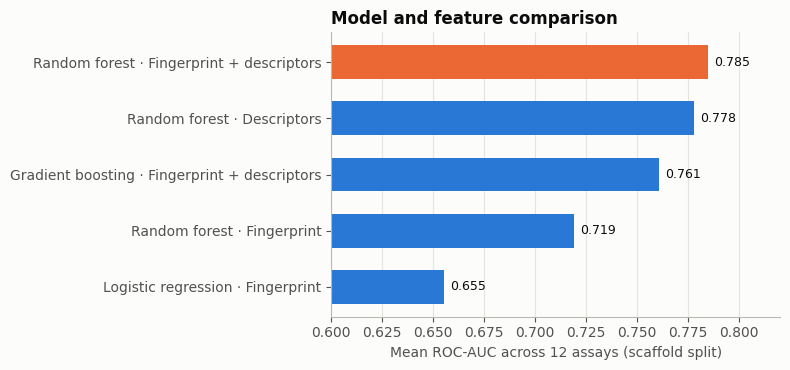

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.8))
colors = [style.ORANGE if "Random forest · Fingerprint + descriptors" == i else style.BLUE for i in comparison.index]
ax.barh(comparison.index, comparison["ROC-AUC"], color=colors, height=0.6)
for i, v in enumerate(comparison["ROC-AUC"]):
    ax.text(v + 0.003, i, f"{v:.3f}", va="center", fontsize=9)
ax.set(xlim=(0.6, 0.82), xlabel="Mean ROC-AUC across 12 assays (scaffold split)", title="Model and feature comparison")
ax.grid(axis="y", visible=False)
save_fig("10_model_comparison")
plt.show()

- **Descriptors beat fingerprints.** Whole-molecule properties such as size and fat solubility generalise better to new scaffolds than the presence of specific fragments. That fits notebook 01, where logP alone separated mitochondrial toxicity well.
- **Combining both is best.** Fragments add information about specific reactive or receptor-binding groups.
- **Gradient boosting does not beat the random forest** here, and it is much slower. On ~6,000 training molecules, a well-regularised forest is hard to beat.

We use **random forest · fingerprint + descriptors** from now on.

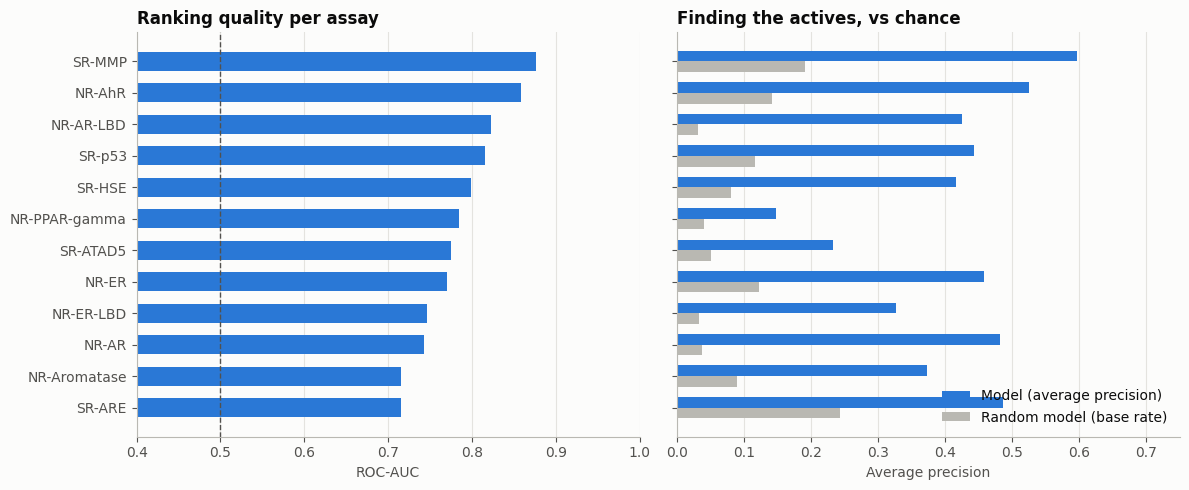

,ROC-AUC,AP,base rate,test molecules
assay,,,,
SR-ARE,0.715,0.486,0.244,476
NR-Aromatase,0.716,0.373,0.090,522
NR-AR,0.742,0.482,0.038,713
NR-ER-LBD,0.746,0.327,0.034,651
NR-ER,0.770,0.458,0.123,554
SR-ATAD5,0.775,0.233,0.051,669
NR-PPAR-gamma,0.785,0.148,0.040,571
SR-HSE,0.799,0.416,0.080,572
SR-p53,0.815,0.443,0.116,628


In [8]:
best = res_scaffold.sort_values("ROC-AUC")
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
axes[0].barh(best.index, best["ROC-AUC"], color=style.BLUE, height=0.6)
axes[0].axvline(0.5, color=style.TEXT_2, lw=1, ls="--")
axes[0].set(xlim=(0.4, 1), xlabel="ROC-AUC", title="Ranking quality per assay")
y = np.arange(len(best))
axes[1].barh(y + 0.17, best["AP"], height=0.34, color=style.BLUE, label="Model (average precision)")
axes[1].barh(y - 0.17, best["base rate"], height=0.34, color=style.NEUTRAL, label="Random model (base rate)")
axes[1].set(xlim=(0, 0.75), xlabel="Average precision", title="Finding the actives, vs chance")
axes[1].legend(loc="lower right")
for ax in axes:
    ax.grid(axis="y", visible=False)
save_fig("11_per_assay_results")
plt.show()
best.round(3)

- The model is strongest for **SR-MMP** (mitochondrial damage) and **NR-AhR**, the two assays with the clearest structure–activity patterns in notebook 01.
- It is weakest for **SR-ARE**, **NR-Aromatase** and **NR-AR** (ROC-AUC 0.72–0.74), where activity probably depends on more specific interactions that 2D features capture poorly.
- In every assay, average precision is between 2 and 13 times the base rate. The model is far better than chance at finding actives, though far from perfect.

## 3. When can we trust a prediction?

A model is only reliable inside its **applicability domain**: the region of chemistry it learned from. We split the scaffold test set into three equal groups by similarity to the nearest training molecule and compute ROC-AUC within each.

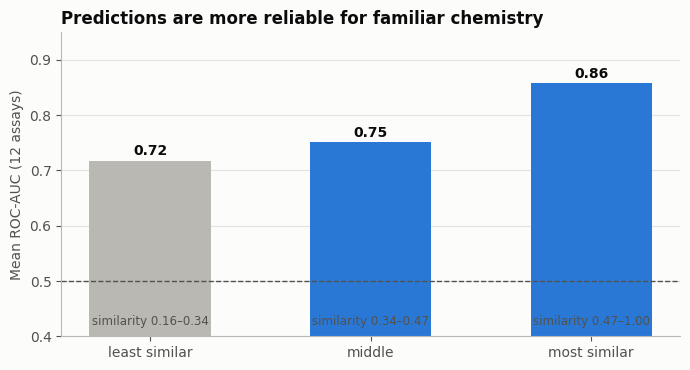

,mean,count,similarity range
group,,,
least similar,0.717,12,0.16–0.34
middle,0.751,12,0.34–0.47
most similar,0.858,12,0.47–1.00


In [9]:
sim_group = pd.qcut(sim_scaffold, 3, labels=["least similar", "middle", "most similar"])
rows = []
for assay in ASSAYS:
    p = preds_scaffold[assay]
    y = mols.loc[p.index, assay]
    for g in sim_group.cat.categories:
        idx = p.index[sim_group.loc[p.index] == g]
        if y[idx].sum() >= 3 and (1 - y[idx]).sum() >= 3:
            rows.append({"assay": assay, "group": g, "ROC-AUC": roc_auc_score(y[idx], p[idx])})
domain = pd.DataFrame(rows)
by_group = domain.groupby("group", observed=True)["ROC-AUC"].agg(["mean", "count"])
ranges = sim_scaffold.groupby(sim_group, observed=True).agg(["min", "max"])
by_group["similarity range"] = [f"{a:.2f}–{b:.2f}" for a, b in ranges.to_numpy()]

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.bar(by_group.index.astype(str), by_group["mean"], color=[style.NEUTRAL, style.BLUE, style.BLUE], width=0.55)
for i, (v, r) in enumerate(zip(by_group["mean"], by_group["similarity range"])):
    ax.text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=10, fontweight="bold")
    ax.text(i, 0.42, f"similarity {r}", ha="center", fontsize=8.5, color=style.TEXT_2)
ax.axhline(0.5, color=style.TEXT_2, lw=1, ls="--")
ax.set(ylim=(0.4, 0.95), ylabel="Mean ROC-AUC (12 assays)", title="Predictions are more reliable for familiar chemistry")
ax.grid(axis="x", visible=False)
save_fig("12_applicability_domain")
plt.show()
by_group.round(3)

For test molecules that resemble something in the training data, the model ranks very well (ROC-AUC ≈ 0.86). For the least familiar third, it drops to ≈ 0.72.
**In practice, every prediction should come with a similarity score**, so that a chemist knows when to trust it. The app in `app/` does exactly this.

## 4. What did the model learn? Toxic fragments

Fingerprint bits stand for molecular fragments, so we can ask which fragments are most **enriched** among active molecules: *"molecules containing this fragment are X times more likely to be active than average"*.
We look at **NR-AhR** and **SR-MMP**, using fragments present in at least 40 tested molecules, and highlight each fragment on an example active molecule.

NR-AhR base rate: 11.7%


,bit,molecules with fragment,% active with fragment,enrichment
0,597,50,50.00,4.26
1,1939,62,48.39,4.12
2,24,83,48.19,4.11
3,1379,44,47.73,4.07
4,885,69,46.38,3.95
5,203,87,45.98,3.92


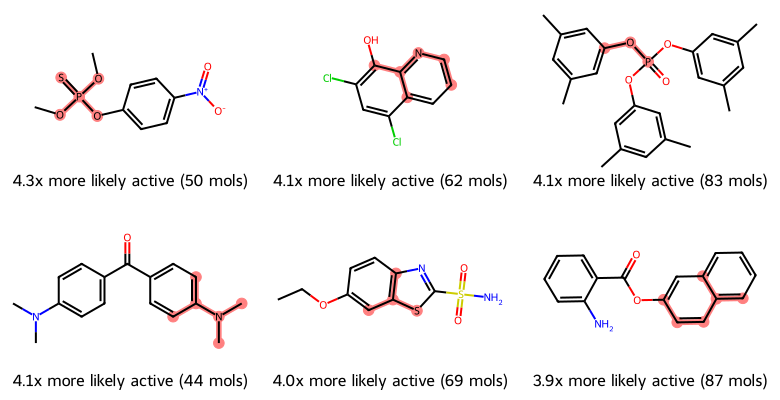

In [10]:
fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=FP_RADIUS, fpSize=FP_BITS)

def fragment_atoms(mol, bit):
    """Atoms covered by fingerprint bit `bit` in `mol` (first occurrence)."""
    ao = rdFingerprintGenerator.AdditionalOutput()
    ao.AllocateBitInfoMap()
    fp_gen.GetFingerprint(mol, additionalOutput=ao)
    centre, radius = ao.GetBitInfoMap()[bit][0]
    if radius == 0:
        return [centre]
    atoms = {centre}
    for b in Chem.FindAtomEnvironmentOfRadiusN(mol, radius, centre):
        bond = mol.GetBondWithIdx(b)
        atoms.update([bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()])
    return sorted(atoms)

def enriched_fragments(assay, min_count=40, top=6):
    tested = mols[assay].notna().to_numpy()
    y = mols.loc[tested, assay].to_numpy()
    F = fps[tested]
    present = F.sum(axis=0)
    rate_with = (F * y[:, None]).sum(axis=0) / np.maximum(present, 1)
    enrichment = rate_with / y.mean()
    ok = present >= min_count
    bits = np.argsort(-np.where(ok, enrichment, 0))[:top]
    return pd.DataFrame({"bit": bits, "molecules with fragment": present[bits],
                         "% active with fragment": rate_with[bits] * 100, "enrichment": enrichment[bits]})

def draw_fragments(assay, frags, name):
    pics, highlights, legends = [], [], []
    for _, row in frags.iterrows():
        bit = int(row["bit"])
        has = (fps[:, bit] == 1) & (mols[assay] == 1).to_numpy()
        example = Chem.MolFromSmiles(mols.loc[has, "smiles_clean"].iloc[0])
        pics.append(example)
        highlights.append(fragment_atoms(example, bit))
        legends.append(f"{row['enrichment']:.1f}x more likely active ({int(row['molecules with fragment'])} mols)")
    img = Draw.MolsToGridImage(pics, molsPerRow=3, subImgSize=(260, 200), legends=legends, highlightAtomLists=highlights)
    path = FIG / f"{name}.png"
    path.write_bytes(img.data) if hasattr(img, "data") else img.save(path)
    return img

overall = mols["NR-AhR"].mean()
ahr = enriched_fragments("NR-AhR")
print(f"NR-AhR base rate: {overall:.1%}")
display(ahr.round(2))
draw_fragments("NR-AhR", ahr, "13_fragments_AhR")

SR-MMP base rate: 15.8%


,bit,molecules with fragment,% active with fragment,enrichment
0,202,170,57.06,3.61
1,1339,75,56.00,3.54
2,1778,125,54.40,3.44
3,419,97,51.55,3.26
4,1602,596,48.49,3.07
5,1313,196,47.45,3.00


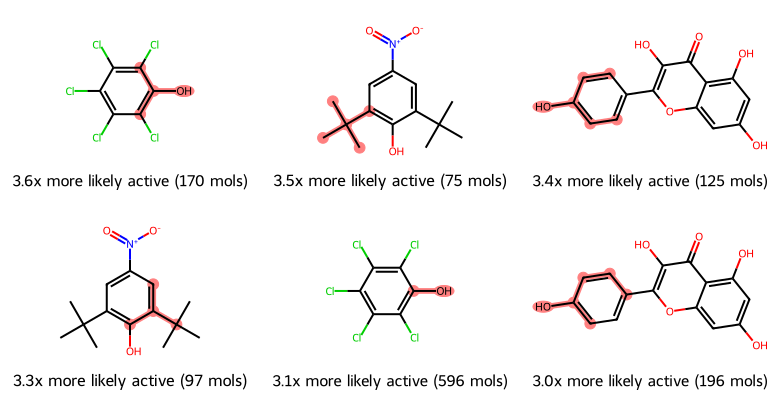

In [11]:
mmp = enriched_fragments("SR-MMP")
print(f"SR-MMP base rate: {mols['SR-MMP'].mean():.1%}")
display(mmp.round(2))
draw_fragments("SR-MMP", mmp, "14_fragments_MMP")

Highlighted atoms show the enriched fragment, and the patterns are chemically familiar:
- **NR-AhR:** fused or linked **aromatic ring systems** (quinolines, naphthalenes, benzothiazoles, aryl phosphates). These are flat aromatic molecules of the kind the "dioxin receptor" binds.
- **SR-MMP:** **lipophilic phenols**, including pentachlorophenol and bulky nitrophenols. These are classic mitochondrial *uncouplers*: weak acids that carry protons across the mitochondrial membrane and short-circuit the cell's energy production.
This is a sanity check rather than proof. Enrichment is a simple association, and a fragment can be enriched because it often appears alongside the truly responsible group.

## 5. How useful is it in practice?

In drug discovery, models are used to **prioritise**: test the top-ranked compounds first. A practical metric is the **enrichment factor**: if we only look at the 10% of molecules the model ranks as most likely toxic, how many more actives do we find than with a random 10%?

In [12]:
rows = []
for assay in ASSAYS:
    p = preds_scaffold[assay]
    y = mols.loc[p.index, assay]
    top = p.nlargest(int(np.ceil(0.10 * len(p)))).index
    rows.append({"assay": assay, "active rate overall": y.mean(), "active rate in top 10%": y[top].mean(),
                 "share of all actives found": y[top].sum() / y.sum()})
ef = pd.DataFrame(rows).set_index("assay")
ef["enrichment factor"] = ef["active rate in top 10%"] / ef["active rate overall"]
print(f"Mean enrichment factor at 10%: {ef['enrichment factor'].mean():.1f}x")
print(f"Mean share of actives found by testing only the top 10%: {ef['share of all actives found'].mean():.0%}")
ef.round(2).sort_values("enrichment factor", ascending=False)

Mean enrichment factor at 10%: 4.0x
Mean share of actives found by testing only the top 10%: 41%


,active rate overall,active rate in top 10%,share of all actives found,enrichment factor
assay,,,,
NR-AR,0.04,0.19,0.52,5.13
NR-AR-LBD,0.03,0.16,0.50,4.93
SR-HSE,0.08,0.38,0.48,4.72
NR-ER-LBD,0.03,0.15,0.45,4.48
SR-ATAD5,0.05,0.22,0.44,4.41
SR-p53,0.12,0.49,0.42,4.23
NR-PPAR-gamma,0.04,0.16,0.39,3.85
NR-AhR,0.14,0.52,0.37,3.67
NR-ER,0.12,0.43,0.35,3.49


Testing only the 10% of new molecules the model ranks highest finds actives at **4 times the random rate** on average, and recovers about **40% of all the toxic ones**. That is the kind of result that saves lab time and money, **even with a model that is far from perfect**.

## Conclusions
1. **How you evaluate matters as much as which model you pick.** A random split overstates performance (ROC-AUC 0.83 vs 0.79). Scaffold splits give the honest estimate for new chemistry.
2. **Simple whole-molecule descriptors carry most of the signal**, and fingerprints add a little. A random forest on both was the best of the models tried.
3. **Trust depends on similarity.** Accuracy drops for molecules unlike the training set, so predictions should always come with a similarity score.
4. **The model learned chemically sensible patterns** (aromatic systems for AhR, uncoupling phenols for mitochondrial toxicity) and is useful for **prioritising** compounds, with 4-fold enrichment in the top 10%.

## Limitations and next steps
- Assay results are noisy, and "inactive" in a screen is not proof of safety.
- 2D features ignore 3D shape. Receptor assays may benefit from 3D or learned representations.
- **Next:** graph neural networks (learning features directly from the molecular graph), multi-task learning across related assays, and calibrated or conformal predictions that give a confidence level for each molecule.